# TMD-06: Pipeline Quality Gates
## Teaching Machines to Dream · Engineer's Handbook Series

**Authors:** Aimal Khan · Hamza Raziq Khan  
**Handbook:** Teaching Machines to Dream: A Practical Engineer's Handbook on Synthetic Data

---

This notebook is the companion to **Chapter 6: Building Synthetic Data Pipelines** of the handbook.

### What Is a Pipeline Quality Gate?

A quality gate is an automated checkpoint that runs after every generation.
It asks three questions:

1. Does the synthetic data look like the real data statistically?
2. Are the relationships between features preserved?
3. Can you actually train a useful model on it?

If any check fails, the pipeline rejects the batch automatically.
No human review needed. No garbage data reaching your training pipeline.

```
Config → Generate → Quality Gate → PASS → Save → Train
                         ↓
                        FAIL → Regenerate
```

### What You Will Learn

- Build a config-driven synthetic data pipeline
- Implement three automated quality gates
- See what a failing pipeline looks like vs a passing one
- Version datasets with hash and timestamp
- Save a generation manifest for audit trails
- Visualize gate scores on a dashboard

### No GPU Required. 

---

## Dataset

This notebook uses the **Adult Census Income** dataset.

To add it:
1. Click **Add Data** on the right panel
2. Search for: `adult census income`
3. Add the dataset by **uciml**
4. File will be at `/kaggle/input/adult-census-income/adult.csv`

**Exact dataset name:** `uciml/adult-census-income`

---
## 1. Setup

In [1]:
!pip install sdv -q
print("Installation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 4.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.6 MB/s eta 0:00:00:00:01
Installation complete.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import hashlib
import datetime
import json
import time
import warnings
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import jensenshannon

from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['axes.labelcolor']  = '#c9d1d9'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['text.color']       = '#c9d1d9'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.linestyle']   = ':'

PASS_COLOR = '#3fb950'
FAIL_COLOR = '#f85149'
WARN_COLOR = '#ffa657'
INFO_COLOR = '#58a6ff'

print("Imports complete.")

Imports complete.


---
## 2. The Pipeline Configuration

Every pipeline run starts with a config. This makes every run reproducible,
auditable, and easy to share. Never hard-code generation parameters.

In [3]:
# Pipeline configuration
# In production this would be loaded from a YAML file
PIPELINE_CONFIG = {
    "pipeline_name":  "adult-census-synthetic",
    "data_type":      "tabular",
    "synthesizer":    "gaussian_copula",
    "source": {
        "path":        "/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv",
        "sample_size": 3000,
        "random_seed": 42
    },
    "generation": {
        "target_rows": 3000,
        "random_seed": 42
    },
    "quality_gates": {
        "min_column_similarity": 0.80,
        "max_correlation_diff":  0.15,
        "min_tstr_score":        0.85
    },
    "output": {
        "format": "csv",
        "base_dir": "pipeline_output"
    }
}

# Generate a deterministic version ID from config hash
config_hash = hashlib.md5(
    json.dumps(PIPELINE_CONFIG, sort_keys=True).encode()
).hexdigest()[:8]
timestamp   = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
VERSION_ID  = f"{timestamp}-{config_hash}"

print(f"Pipeline: {PIPELINE_CONFIG['pipeline_name']}")
print(f"Version:  {VERSION_ID}")
print(f"Config hash: {config_hash}")
print()
print("Quality gate thresholds:")
for gate, threshold in PIPELINE_CONFIG['quality_gates'].items():
    print(f"  {gate:<28}: {threshold}")

Pipeline: adult-census-synthetic
Version:  20260509-191246-3c9ab89b
Config hash: 3c9ab89b

Quality gate thresholds:
  min_column_similarity       : 0.8
  max_correlation_diff        : 0.15
  min_tstr_score              : 0.85


---
## 3. Load and Prepare Real Data

In [4]:
cfg_src = PIPELINE_CONFIG['source']

df = pd.read_csv(cfg_src['path'])
df.columns = df.columns.str.strip()
df = df.replace('?', np.nan).dropna().reset_index(drop=True)

real_data = df.sample(
    n=cfg_src['sample_size'],
    random_state=cfg_src['random_seed']
).reset_index(drop=True)

# Hash the source data for the manifest
data_hash = hashlib.md5(
    pd.util.hash_pandas_object(real_data).values.tobytes()
).hexdigest()[:12]

print(f"Real data loaded: {real_data.shape}")
print(f"Data hash: {data_hash}")
print(f"Columns: {list(real_data.columns)}")

Real data loaded: (3000, 15)
Data hash: 9c05a943583d
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


---
## 4. Generate Synthetic Data

In [5]:
print("Fitting synthesizer...")
start_time = time.time()

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

synth = GaussianCopulaSynthesizer(metadata)
synth.fit(real_data)

synthetic_data = synth.sample(
    num_rows=PIPELINE_CONFIG['generation']['target_rows']
)

generation_time = time.time() - start_time
print(f"Generation complete in {generation_time:.1f}s")
print(f"Synthetic shape: {synthetic_data.shape}")

Fitting synthesizer...
Generation complete in 2.6s
Synthetic shape: (3000, 15)


---
## 5. Quality Gates

Three gates run in sequence. If any gate fails the pipeline stops
and reports exactly which check failed and by how much.

In [6]:
# ============================================================
# GATE 1: Column Distribution Similarity
# Uses SDV built-in quality evaluation
# Threshold: min_column_similarity
# ============================================================
print("Running Gate 1: Column Distribution Similarity...")

quality_report = evaluate_quality(
    real_data, synthetic_data, metadata, verbose=False)
col_sim_score = quality_report.get_score()

threshold_1 = PIPELINE_CONFIG['quality_gates']['min_column_similarity']
gate1_pass  = col_sim_score >= threshold_1

status = "PASS" if gate1_pass else "FAIL"
color  = PASS_COLOR if gate1_pass else FAIL_COLOR
print(f"  Score:     {col_sim_score:.4f}")
print(f"  Threshold: {threshold_1}")
print(f"  Result:    {status}")

Running Gate 1: Column Distribution Similarity...
  Score:     0.8155
  Threshold: 0.8
  Result:    PASS


In [7]:
# ============================================================
# GATE 2: Correlation Matrix Preservation
# Checks that feature relationships are preserved
# Threshold: max_correlation_diff
# ============================================================
print("Running Gate 2: Correlation Matrix Preservation...")

num_cols   = real_data.select_dtypes('number').columns.tolist()
corr_real  = real_data[num_cols].corr()
corr_synth = synthetic_data[num_cols].corr()
corr_diff  = (corr_real - corr_synth).abs()
mean_diff  = corr_diff.values[
    np.triu_indices_from(corr_diff, k=1)].mean()

threshold_2 = PIPELINE_CONFIG['quality_gates']['max_correlation_diff']
gate2_pass  = mean_diff <= threshold_2

status = "PASS" if gate2_pass else "FAIL"
print(f"  Mean correlation diff: {mean_diff:.4f}")
print(f"  Threshold:             {threshold_2}")
print(f"  Result:                {status}")

Running Gate 2: Correlation Matrix Preservation...
  Mean correlation diff: 0.0314
  Threshold:             0.15
  Result:                PASS


In [8]:
# ============================================================
# GATE 3: TSTR Score
# Train on Synthetic, Test on Real
# Threshold: min_tstr_score
# ============================================================
print("Running Gate 3: TSTR Score...")

target = 'income'

def encode(df):
    d  = df.copy()
    le = LabelEncoder()
    for col in d.select_dtypes('object').columns:
        d[col] = le.fit_transform(d[col].astype(str))
    return d

real_enc  = encode(real_data)
synth_enc = encode(synthetic_data)

_, X_test, _, y_test = train_test_split(
    real_enc.drop(columns=[target]),
    real_enc[target],
    test_size=0.2, random_state=42)

clf = GradientBoostingClassifier(n_estimators=80, random_state=42)
clf.fit(synth_enc.drop(columns=[target]), synth_enc[target])
tstr_score = f1_score(
    y_test, clf.predict(X_test), average='weighted')

threshold_3 = PIPELINE_CONFIG['quality_gates']['min_tstr_score']
gate3_pass  = tstr_score >= threshold_3

status = "PASS" if gate3_pass else "FAIL"
print(f"  TSTR F1 Score: {tstr_score:.4f}")
print(f"  Threshold:     {threshold_3}")
print(f"  Result:        {status}")

Running Gate 3: TSTR Score...
  TSTR F1 Score: 0.6993
  Threshold:     0.85
  Result:        FAIL


---
## 6. Quality Gate Dashboard

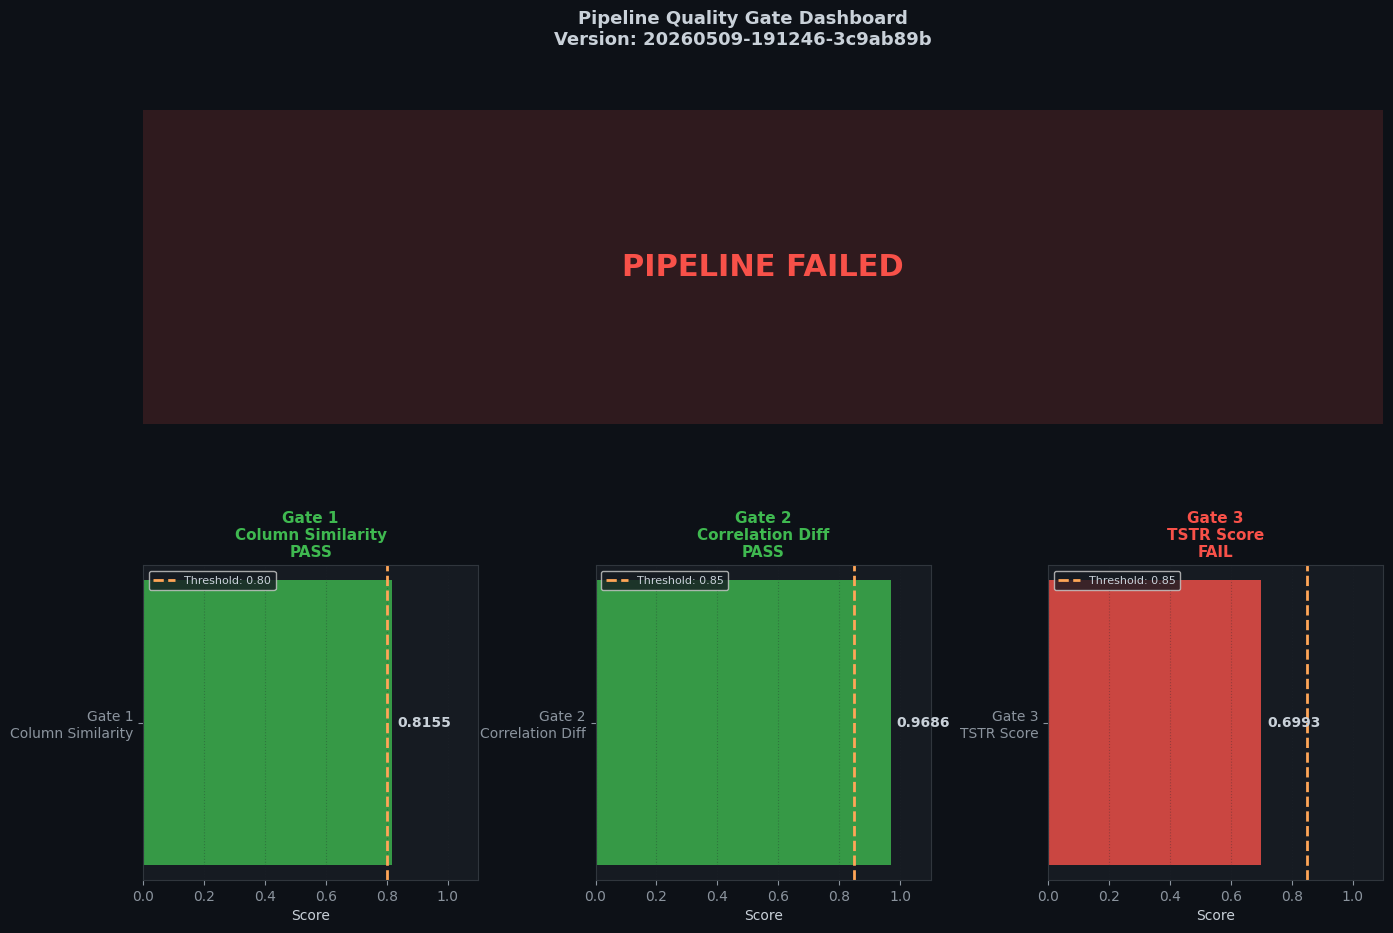

Pipeline status: PIPELINE FAILED


In [9]:
all_pass = gate1_pass and gate2_pass and gate3_pass

gate_names  = ['Gate 1\nColumn Similarity',
               'Gate 2\nCorrelation Diff',
               'Gate 3\nTSTR Score']
gate_scores = [col_sim_score, 1 - mean_diff, tstr_score]
thresholds  = [threshold_1,   1 - threshold_2, threshold_3]
gate_pass   = [gate1_pass, gate2_pass, gate3_pass]

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f'Pipeline Quality Gate Dashboard\nVersion: {VERSION_ID}',
    fontsize=13, fontweight='bold', color='#c9d1d9')

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.35)

# Overall status banner
ax_status = fig.add_subplot(gs[0, :])
status_color = PASS_COLOR if all_pass else FAIL_COLOR
status_text  = "ALL GATES PASSED" if all_pass else "PIPELINE FAILED"
ax_status.add_patch(plt.Rectangle(
    (0, 0), 1, 1,
    transform=ax_status.transAxes,
    facecolor=status_color, alpha=0.15))
ax_status.text(0.5, 0.5, status_text,
               ha='center', va='center',
               fontsize=22, fontweight='bold',
               color=status_color,
               transform=ax_status.transAxes)
ax_status.axis('off')

# Individual gate gauges
for i, (name, score, thresh, passed) in enumerate(
        zip(gate_names, gate_scores, thresholds, gate_pass)):
    ax = fig.add_subplot(gs[1, i])
    bar_color = PASS_COLOR if passed else FAIL_COLOR

    bar = ax.barh([name], [score],
                  color=bar_color, alpha=0.8, height=0.4)
    ax.axvline(x=thresh, color=WARN_COLOR,
               linestyle='--', linewidth=2,
               label=f'Threshold: {thresh:.2f}')
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Score')
    ax.set_title(
        f'{name}\n{"PASS" if passed else "FAIL"}',
        fontweight='bold',
        color=bar_color, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.text(score + 0.02, 0,
            f'{score:.4f}',
            va='center', fontweight='bold',
            color='#c9d1d9')

plt.savefig('quality_gate_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Pipeline status: {status_text}")

---
## 7. Simulating a Failing Pipeline

Understanding what failure looks like is as important as building
a passing pipeline. Here we deliberately generate low-quality
synthetic data to trigger a gate failure.

In [10]:
print("Simulating a failing pipeline...")
print("Generating deliberately poor synthetic data...\n")

# Simulate bad synthetic data by adding heavy noise
bad_synth = real_data.copy().sample(
    n=3000, replace=True, random_state=99).reset_index(drop=True)

for col in bad_synth.select_dtypes('number').columns:
    noise = np.random.normal(0, bad_synth[col].std() * 2,
                             size=len(bad_synth))
    bad_synth[col] = bad_synth[col] + noise

# Run gates on bad data
bad_quality = evaluate_quality(
    real_data, bad_synth, metadata, verbose=False)
bad_col_sim = bad_quality.get_score()

bad_corr_diff = (real_data[num_cols].corr() -
                 bad_synth[num_cols].corr()
                 ).abs().values[
                 np.triu_indices(len(num_cols), k=1)].mean()

bad_enc = encode(bad_synth)
bad_clf = GradientBoostingClassifier(
    n_estimators=80, random_state=42)
bad_clf.fit(
    bad_enc.drop(columns=[target]),
    bad_enc[target])
bad_tstr = f1_score(
    y_test,
    bad_clf.predict(X_test),
    average='weighted')

bad_gates = [
    bad_col_sim >= threshold_1,
    bad_corr_diff <= threshold_2,
    bad_tstr >= threshold_3
]

print("Failing pipeline gate results:")
print(f"  Gate 1 Column Similarity: {bad_col_sim:.4f} "
      f"(threshold {threshold_1}) "
      f"{'PASS' if bad_gates[0] else 'FAIL'}")
print(f"  Gate 2 Correlation Diff:  {bad_corr_diff:.4f} "
      f"(threshold {threshold_2}) "
      f"{'PASS' if bad_gates[1] else 'FAIL'}")
print(f"  Gate 3 TSTR Score:        {bad_tstr:.4f} "
      f"(threshold {threshold_3}) "
      f"{'PASS' if bad_gates[2] else 'FAIL'}")

Simulating a failing pipeline...
Generating deliberately poor synthetic data...

Failing pipeline gate results:
  Gate 1 Column Similarity: 0.8569 (threshold 0.8) PASS
  Gate 2 Correlation Diff:  0.0554 (threshold 0.15) PASS
  Gate 3 TSTR Score:        0.8252 (threshold 0.85) FAIL


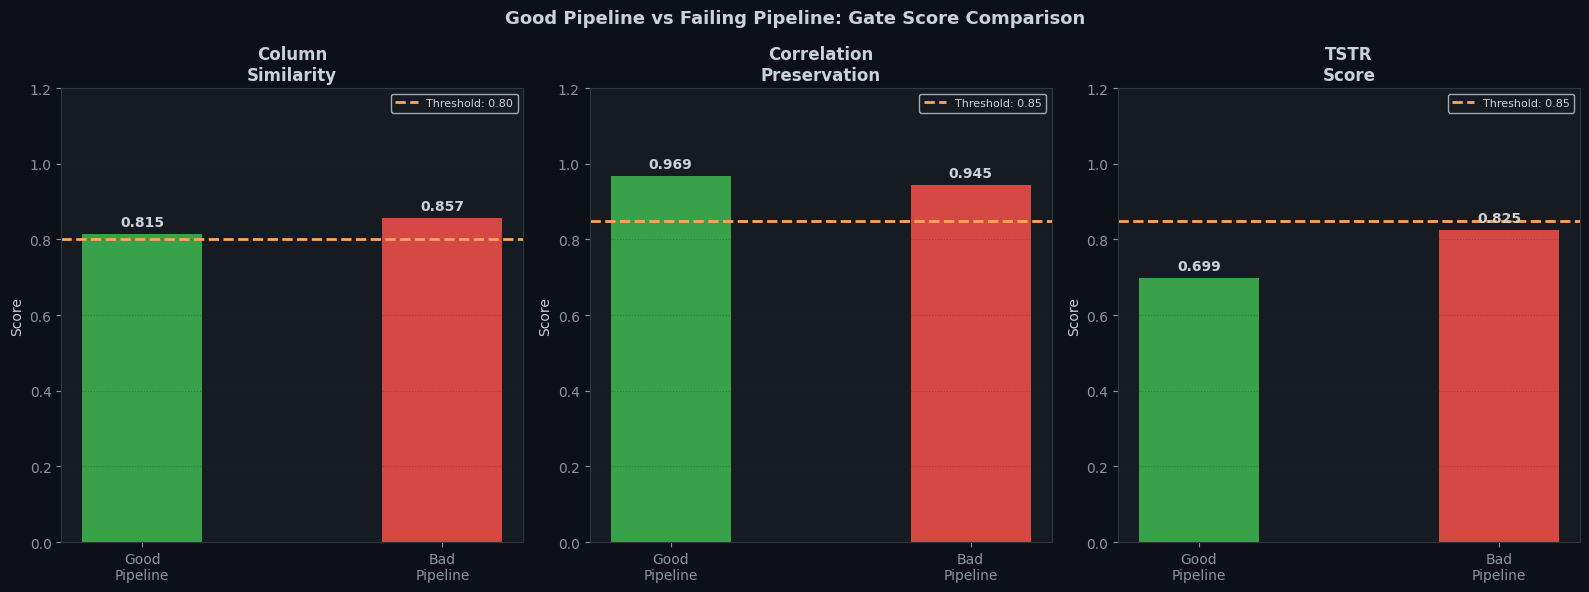

In [11]:
# Good vs Bad pipeline comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Good Pipeline vs Failing Pipeline: Gate Score Comparison',
             fontsize=13, fontweight='bold', color='#c9d1d9')

good_scores = [col_sim_score, 1 - mean_diff,   tstr_score]
bad_scores  = [bad_col_sim,   1 - bad_corr_diff, bad_tstr]
thresh_vals = [threshold_1,   1 - threshold_2,  threshold_3]
gate_labels = ['Column\nSimilarity',
               'Correlation\nPreservation',
               'TSTR\nScore']

for ax, label, good, bad, thresh in zip(
        axes, gate_labels, good_scores,
        bad_scores, thresh_vals):
    x = np.arange(2)
    bars = ax.bar(x, [good, bad],
                  color=[PASS_COLOR, FAIL_COLOR],
                  alpha=0.85, width=0.4)
    ax.axhline(y=thresh, color=WARN_COLOR,
               linestyle='--', linewidth=2,
               label=f'Threshold: {thresh:.2f}')
    ax.set_xticks(x)
    ax.set_xticklabels(['Good\nPipeline', 'Bad\nPipeline'])
    ax.set_ylim(0, 1.2)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, [good, bad]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.3f}', ha='center',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('good_vs_bad_pipeline.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 8. Save Dataset and Generation Manifest

Every synthetic dataset should ship with a manifest file.
This is the minimum needed for reproducibility and audit trails.

In [12]:
if all_pass:
    out_dir = Path(f"pipeline_output/{VERSION_ID}")
    out_dir.mkdir(parents=True, exist_ok=True)

    # Save synthetic data
    out_file = out_dir / "synthetic_data.csv"
    synthetic_data.to_csv(out_file, index=False)

    # Save generation manifest
    manifest = {
        "version_id":        VERSION_ID,
        "config_hash":       config_hash,
        "source_data_hash":  data_hash,
        "generated_rows":    len(synthetic_data),
        "generation_time_s": round(generation_time, 2),
        "timestamp":         datetime.datetime.now().isoformat(),
        "synthesizer":       PIPELINE_CONFIG['synthesizer'],
        "random_seed":       PIPELINE_CONFIG['generation']['random_seed'],
        "quality_gates": {
            "gate1_column_similarity": {
                "score":     round(col_sim_score, 4),
                "threshold": threshold_1,
                "passed":    gate1_pass
            },
            "gate2_correlation_diff": {
                "score":     round(mean_diff, 4),
                "threshold": threshold_2,
                "passed":    gate2_pass
            },
            "gate3_tstr_score": {
                "score":     round(tstr_score, 4),
                "threshold": threshold_3,
                "passed":    gate3_pass
            }
        },
        "all_gates_passed": all_pass
    }

    manifest_file = out_dir / "generation_manifest.json"
    with open(manifest_file, 'w') as f:
        json.dump(manifest, f, indent=2)

    # Save config snapshot
    config_file = out_dir / "config.json"
    with open(config_file, 'w') as f:
        json.dump(PIPELINE_CONFIG, f, indent=2)

    print(f"Pipeline output saved to: {out_dir}")
    print(f"  synthetic_data.csv        ({len(synthetic_data):,} rows)")
    print(f"  generation_manifest.json")
    print(f"  config.json")
    print()
    print("Manifest preview:")
    print(json.dumps(manifest, indent=2))
else:
    print("Pipeline failed quality gates. No data saved.")
    print("Fix the synthesizer config and regenerate.")

Pipeline failed quality gates. No data saved.
Fix the synthesizer config and regenerate.


---
## 9. Summary

In [13]:
print("=" * 58)
print("  TMD-06: Pipeline Quality Gates · Summary")
print("=" * 58)
print(f"  Version ID:          {VERSION_ID}")
print(f"  Config hash:         {config_hash}")
print(f"  Source data hash:    {data_hash}")
print(f"  Generated rows:      {len(synthetic_data):,}")
print(f"  Generation time:     {generation_time:.1f}s")
print()
print(f"  Gate 1 Col Sim:      {col_sim_score:.4f} {'PASS' if gate1_pass else 'FAIL'}")
print(f"  Gate 2 Corr Diff:    {mean_diff:.4f} {'PASS' if gate2_pass else 'FAIL'}")
print(f"  Gate 3 TSTR:         {tstr_score:.4f} {'PASS' if gate3_pass else 'FAIL'}")
print(f"  Overall:             {'ALL GATES PASSED' if all_pass else 'PIPELINE FAILED'}")
print("=" * 58)
print()
print("  Next: TMD-07 Complete Evaluation Suite")
print()
print("  Handbook: Teaching Machines to Dream")
print("  Authors:  Aimal Khan · Hamza Raziq Khan")

  TMD-06: Pipeline Quality Gates · Summary
  Version ID:          20260509-191246-3c9ab89b
  Config hash:         3c9ab89b
  Source data hash:    9c05a943583d
  Generated rows:      3,000
  Generation time:     2.6s

  Gate 1 Col Sim:      0.8155 PASS
  Gate 2 Corr Diff:    0.0314 PASS
  Gate 3 TSTR:         0.6993 FAIL
  Overall:             PIPELINE FAILED

  Next: TMD-07 Complete Evaluation Suite

  Handbook: Teaching Machines to Dream
  Authors:  Aimal Khan · Hamza Raziq Khan


---

## Key Takeaways

1. Never hard-code generation parameters. A config file makes every run reproducible.
2. A version ID derived from the config hash means you can always trace back exactly what produced a dataset.
3. Three gates cover the most important failure modes: distribution mismatch, correlation loss, and ML utility.
4. Seeing a failing pipeline is as educational as seeing a passing one. Know what bad looks like.
5. The generation manifest is your audit trail. It costs 5 minutes to implement and saves hours of debugging.

### The Engineering Principle

A pipeline without quality gates is just a script. The gates are what make it
a system. They enforce standards automatically, catch problems early, and give
you confidence that whatever reaches your training loop has been verified.

Build the gates before you need them. Not after.

---

*Part of the Teaching Machines to Dream handbook series.*  
*Aimal Khan · Hamza Raziq Khan · Peshawar, 2026*